In [1]:
import pandas as pd
import matplotlib.pyplot as plt

knime_output = pd.read_csv(r"C:\Users\deepj\Documents\knime-automated-analytics-workflow\data\processed\retail_kpis.csv")
print(knime_output.shape)
knime_output.head()

(187, 4)


,SKU_Category,Sum(Sales_Amount),Sum(Quantity),Count*(Transaction_ID)
0,01F,38029.87,3904.00,2158
1,06Z,8619.17,216.67,209
2,0H2,29875.14,4639.00,4500
3,0KX,2044.45,483.00,460
4,0WT,4052.49,715.00,673


In [2]:
category_revenue = knime_output.groupby("SKU_Category")["Sum(Sales_Amount)"].sum().reset_index()
category_revenue.columns = ["category", "total_revenue"]
category_revenue = category_revenue.sort_values("total_revenue", ascending=False)
category_revenue

,category,total_revenue
30,6BZ,114061.33
155,SJS,85142.31
106,LPF,84921.91
131,OXH,54470.16
119,N8U,49119.55
...,...,...
81,H4E,35.28
82,H8J,22.96
144,QON,12.75
173,WWM,7.33


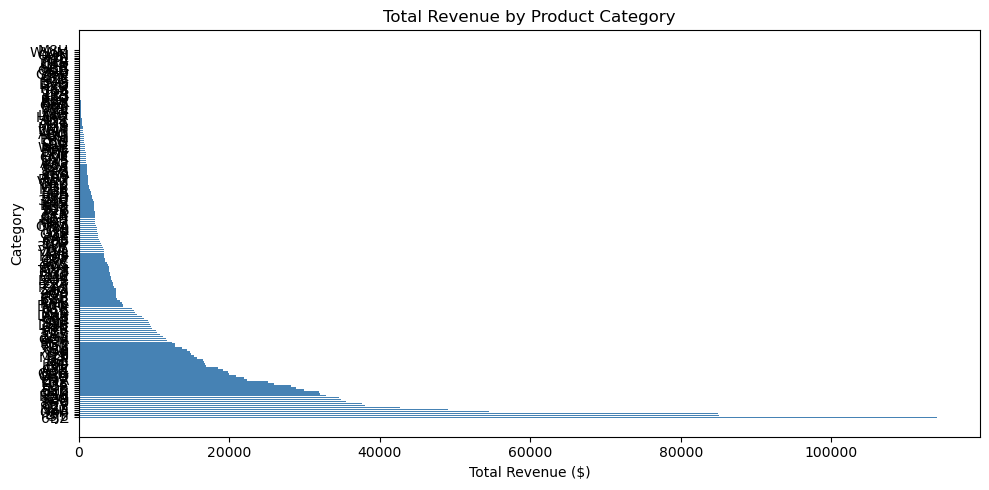

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(category_revenue["category"], category_revenue["total_revenue"], color="steelblue")
ax.set(title="Total Revenue by Product Category", xlabel="Total Revenue ($)", ylabel="Category")
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\knime-automated-analytics-workflow\reports\revenue_by_category.png")
plt.show()

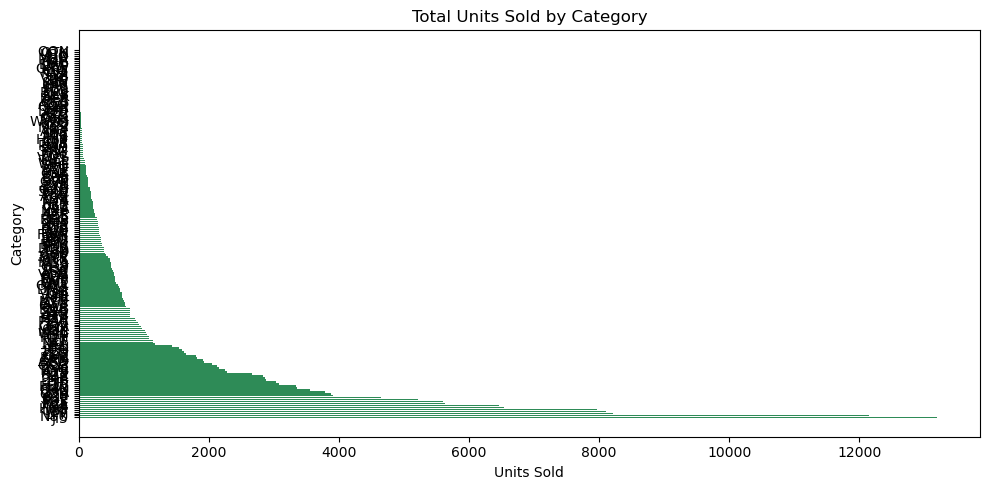

In [4]:
category_units = knime_output.groupby("SKU_Category")["Sum(Quantity)"].sum().reset_index()
category_units.columns = ["category", "total_units"]
category_units = category_units.sort_values("total_units", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(category_units["category"], category_units["total_units"], color="seagreen")
ax.set(title="Total Units Sold by Category", xlabel="Units Sold", ylabel="Category")
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\knime-automated-analytics-workflow\reports\units_by_category.png")
plt.show()

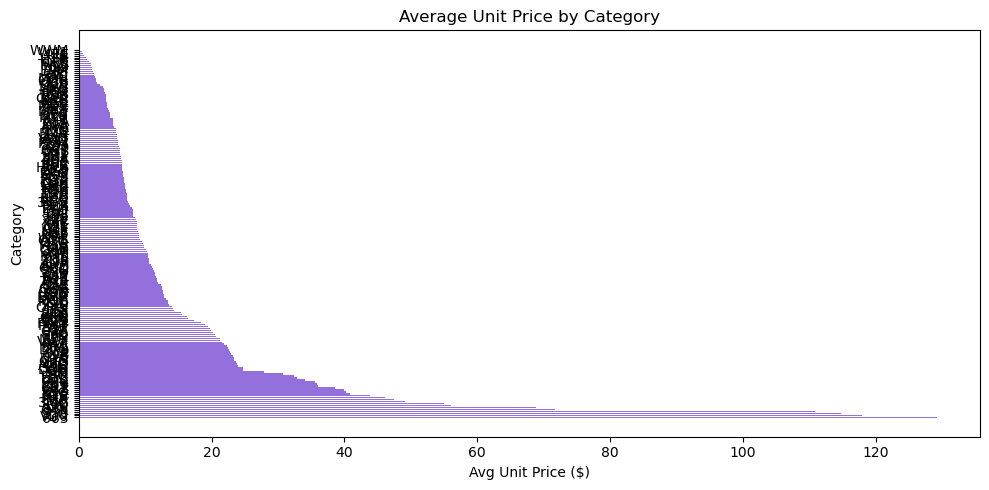

In [5]:
raw = pd.read_csv(r"C:\Users\deepj\Documents\knime-automated-analytics-workflow\data\raw\retail_sales.csv")
raw["Unit_Price"] = raw["Sales_Amount"] / raw["Quantity"]

avg_price = raw.groupby("SKU_Category")["Unit_Price"].mean().reset_index()
avg_price.columns = ["category", "avg_unit_price"]
avg_price = avg_price.sort_values("avg_unit_price", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(avg_price["category"], avg_price["avg_unit_price"], color="mediumpurple")
ax.set(title="Average Unit Price by Category", xlabel="Avg Unit Price ($)", ylabel="Category")
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\knime-automated-analytics-workflow\reports\avg_price_by_category.png")
plt.show()

In [7]:
print(knime_output.columns.tolist())

['SKU_Category', 'Sum(Sales_Amount)', 'Sum(Quantity)', 'Count*(Transaction_ID)']


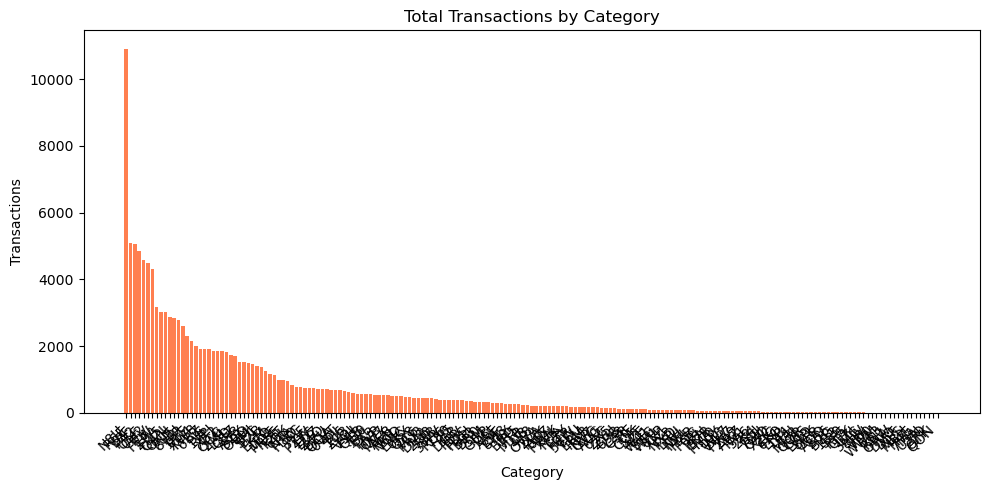

In [8]:
transactions = knime_output.groupby("SKU_Category")["Count*(Transaction_ID)"].sum().reset_index()
transactions.columns = ["category", "total_transactions"]
transactions = transactions.sort_values("total_transactions", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(transactions["category"], transactions["total_transactions"], color="coral")
ax.set(title="Total Transactions by Category", xlabel="Category", ylabel="Transactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"C:\Users\deepj\Documents\knime-automated-analytics-workflow\reports\transactions_by_category.png")
plt.show()

In [9]:
summary = category_revenue.merge(category_units, on="category")
summary = summary.merge(avg_price, on="category")
summary = summary.merge(transactions, on="category")
summary.to_csv(r"C:\Users\deepj\Documents\knime-automated-analytics-workflow\data\processed\category_summary.csv", index=False)
print("saved!")

saved!


In [10]:
raw = pd.read_csv(r"C:\Users\deepj\Documents\knime-automated-analytics-workflow\data\raw\retail_sales.csv")
raw["Unit_Price"] = raw["Sales_Amount"] / raw["Quantity"]

total_revenue = raw["Sales_Amount"].sum()
total_transactions = raw["Transaction_ID"].nunique()
total_units = raw["Quantity"].sum()
avg_unit_price = raw["Unit_Price"].mean()
top_category = category_revenue.iloc[0]["category"]
top_category_revenue = category_revenue.iloc[0]["total_revenue"]
total_categories = raw["SKU_Category"].nunique()
avg_order_value = raw.groupby("Transaction_ID")["Sales_Amount"].sum().mean()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Units Sold: {total_units:,}")
print(f"Avg Unit Price: ${avg_unit_price:,.2f}")
print(f"Avg Order Value: ${avg_order_value:,.2f}")
print(f"Top Category: {top_category} (${top_category_revenue:,.2f})")
print(f"Total Categories: {total_categories}")

Total Revenue: $1,578,038.62
Total Transactions: 64,682
Total Units Sold: 195,624.429
Avg Unit Price: $9.69
Avg Order Value: $24.40
Top Category: 6BZ ($114,061.33)
Total Categories: 187
